# Capítulo 13: Modelos de regressão

<hr>

Códigos do livro: **Probabilidade e Estatística: Teoria, simulação e Dadados**<br>
Site: https://loja.uiclap.com/titulo/ua158988 <br>
Autor: Francisco A. Rodrigues<br>
https://sites.icmc.usp.br/francisco<br>
Universidade de São Paulo<br>
<hr>

Coeficientes estimados:
theta0 (intercepto): 2.033804377944029
theta1 (inclinação): 0.5779994458298697


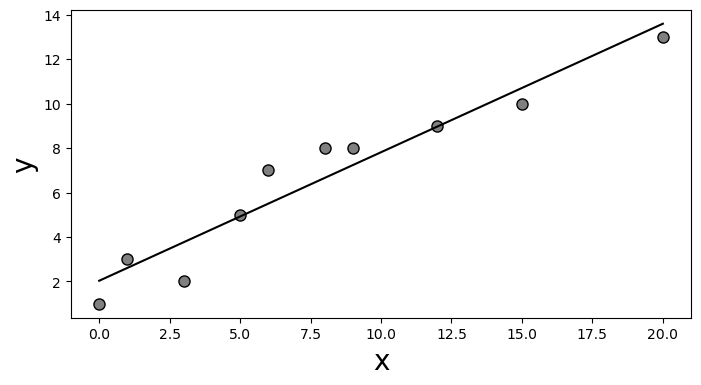

In [1]:
# Pág. 375
import matplotlib.pyplot as plt
import numpy as np

# função para calcular os coeficientes
def estimate_coef(x, y): 
    n = np.size(x) # número de observações
    # valores médios das observações
    m_x, m_y = np.mean(x), np.mean(y) 
    S_xy = 0
    S_xx = 0
    # calcula as somas
    for i in range(0, len(x)):
        S_xy = S_xy + (x[i]-m_x)*(y[i]-m_y)
        S_xx = S_xx + (x[i]-m_x)**2
    # calcula os coeficientes do modelo
    b_1 = S_xy / S_xx 
    b_0 = m_y - b_1*m_x 
    return(b_0, b_1) 

# dados observados
x = np.array([0, 1, 3, 5, 6, 8, 9, 12, 15, 20]) 
y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 13]) 

# realiza o ajuste
b = estimate_coef(x, y) 
y_pred = b[0] + b[1]*x 
print('Coeficientes estimados:') 
print('theta0 (intercepto):', b[0])
print('theta1 (inclinação):', b[1])


# mostra os dados
plt.figure(figsize=(8,4))
plt.plot(x, y, 'o', color='gray', markersize=8, 
         markerfacecolor='gray', 
         markeredgecolor='black')
# mostra o modelo ajustado
plt.plot(x,y_pred, color='black')
plt.xlabel('x', fontsize = 20) 
plt.ylabel('y', fontsize = 20) 
plt.show(True) 

In [2]:
# Pág. 377
# calcula o coeficiente R2
def R2(y,y_hat):
    n = len(y)
    m_y = np.mean(y) 
    RSS = 0; SST = 0
    for i in range(0,len(y)):
        RSS = RSS + (y[i]-y_hat[i])**2
        SST = SST + (y[i]-m_y)**2
    R2 = 1 - RSS/SST
    return R2

print('R2 = ', R2(y, y_pred))

R2 =  0.9246218128842856


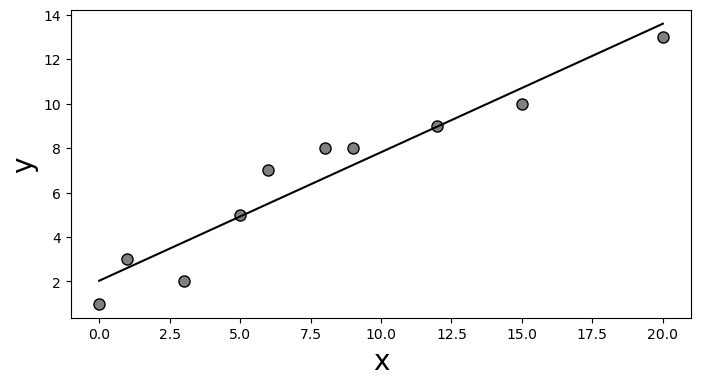

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     98.13
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           9.11e-06
Time:                        11:36:00   Log-Likelihood:                -14.103
No. Observations:                  10   AIC:                             32.21
Df Residuals:                       8   BIC:                             32.81
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0338      0.579      3.512      0.0

In [3]:
# Pág. 382
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
np.random.seed(42)

# dados
x = np.array([0, 1, 3, 5, 6, 8, 9, 12, 15, 20]) 
y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 13]) 

# cria a matriz X
X = np.transpose([np.ones(len(x)),x])
# ajusta o modelo
model = sm.OLS(y, X)
model_adjusted = model.fit()
y_pred = model_adjusted.predict(X)

# mostra os resultados
plt.figure(figsize=(8,4))
plt.plot(x, y, 'o', color='gray', markersize=8, 
         markerfacecolor='gray', 
         markeredgecolor='black')
plt.plot(x,y_pred, color='black')
plt.xlabel('x', fontsize = 20) 
plt.ylabel('y', fontsize = 20) 
plt.show(True) 

# mostra os resultados do modelo
print(model_adjusted.summary())

In [4]:
# Pág. 383
print('IC: ', model_adjusted.conf_int(alpha=0.05))

IC:  [[0.69843503 3.36917372]
 [0.44344957 0.71254932]]


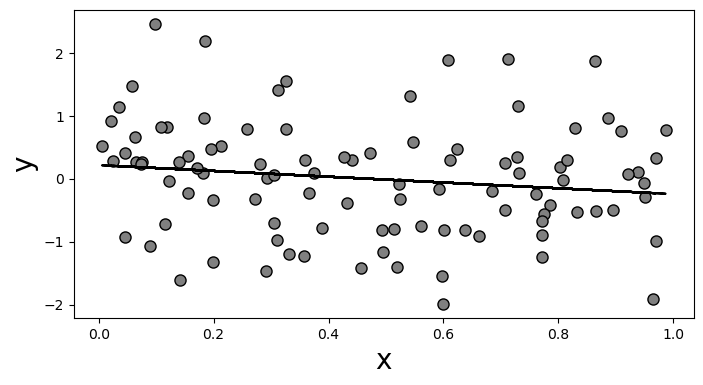

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     2.250
Date:                Mon, 23 Mar 2026   Prob (F-statistic):              0.137
Time:                        11:36:20   Log-Likelihood:                -131.15
No. Observations:                 100   AIC:                             266.3
Df Residuals:                      98   BIC:                             271.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2151      0.170      1.263      0.2

In [5]:
# Pág. 384
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
np.random.seed(42)

# dados
n = 100
x = np.random.uniform(0, 1,n)
y = np.random.normal(0,1, n)

# cria a matriz X
X = np.transpose([np.ones(len(x)),x])
# ajusta o modelo
model = sm.OLS(y, X)
model_adjusted = model.fit()
y_pred = model_adjusted.predict(X)

# mostra os resultados
plt.figure(figsize=(8,4))
plt.plot(x, y, 'o', color='gray', markersize=8, 
         markerfacecolor='gray', 
         markeredgecolor='black')
plt.plot(x,y_pred, color='black')
plt.xlabel('x', fontsize = 20) 
plt.ylabel('y', fontsize = 20) 
plt.show(True) 

# mostra os resultados do modelo
print(model_adjusted.summary())

theta 0 : [6.77043186]
theta 1 : [1.54912282]
theta 2 : [3.02462592]


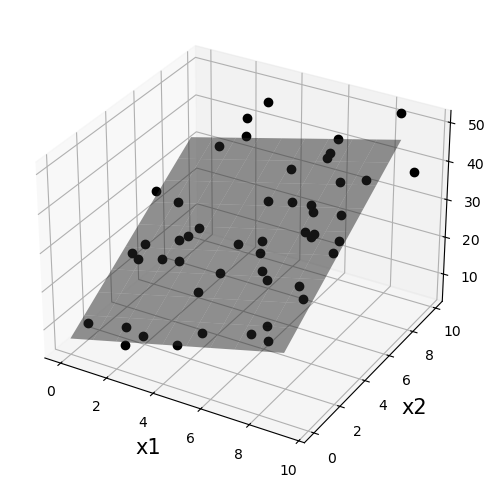

In [6]:
# Pág. 388
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(10)

# gera os dados
n = 50 # número de observações
x0 = np.ones((n, 1))
x1 = np.random.uniform(0,10, (n, 1))
x2 = np.random.uniform(0,10, (n, 1))
e = np.random.normal(0,5, (n, 1))
y = 4 + 2*x1 + 3*x2 + e
# combinando as características em uma matriz [n x 3]
X = np.hstack((x0, x1, x2))

# calcula os thetas usando equação normal
theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
for i in range(0,len(theta)):
    print('theta',i,':',theta[i])

# calcula o plano ajustado
k = 10
p1, p2 = np.mgrid[:k, :k]
P = np.hstack(( np.reshape(p1, (k*k, 1)), 
               np.reshape(p2, (k*k, 1))))
P = np.hstack(( np.ones((k*k, 1)), P))
plane = np.reshape(np.dot(P, theta), (k, k));

# mostra os resultados
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(projection = '3d')
ax.plot(x1[:,0],x2[:,0],y[:,0],'ko') 
ax.plot_surface(p1,p2,plane, color='gray',alpha=.5) 
ax.set_xlabel('x1', fontsize = 15)
ax.set_ylabel('x2', fontsize = 15)
ax.set_zlabel('y', fontsize = 15)
plt.show()

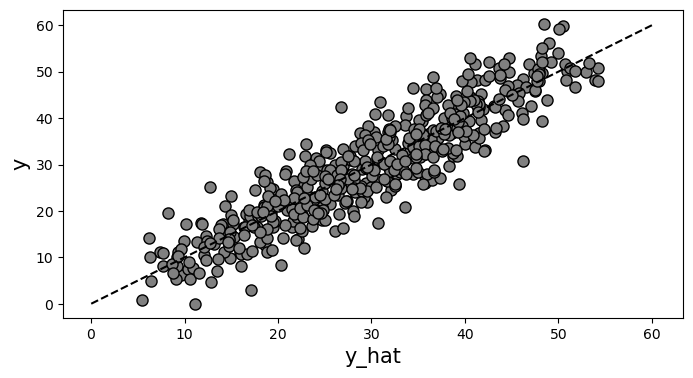

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     767.6
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          6.85e-186
Time:                        11:36:56   Log-Likelihood:                -1519.7
No. Observations:                 500   AIC:                             3047.
Df Residuals:                     496   BIC:                             3064.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9465      0.749      5.267      0.0

In [7]:
# Pág. 390
import pandas as pd
import numpy as np
import statsmodels.api as sm 
import matplotlib.pyplot as plt

np.random.seed(42)

n = 500 # número de observações
# gera os dados
sigma = 5
x0 = np.ones((n, 1)) # x0 com entradas iguais a um
x1 = np.random.uniform(0,10, (n, 1));
x2 = np.random.uniform(0,10, (n, 1));
x3 = np.random.uniform(1,10, (n, 1));
epsilon = np.random.normal(0,sigma, (n, 1))
y = 5*x0 + 2*x1 + 3*x2 + epsilon
X = np.hstack((x0,x1,x2,x3))
# ajusta o modelo
model = sm.OLS(y, X)
model_adjusted = model.fit()
y_pred = model_adjusted.predict(X)

# mostra os resultados
plt.figure(figsize=(8,4))
plt.plot(y_pred, y, 'o', color='gray', markersize=8, 
         markerfacecolor='gray', 
         markeredgecolor='black')
xy = np.arange(np.min(y),np.max(y),0.1)
plt.plot(xy,xy, color='black', linestyle = '--')
plt.xlabel('y_hat', fontsize = 15) 
plt.ylabel('y', fontsize = 15) 
plt.show(True) 
print(model_adjusted.summary())

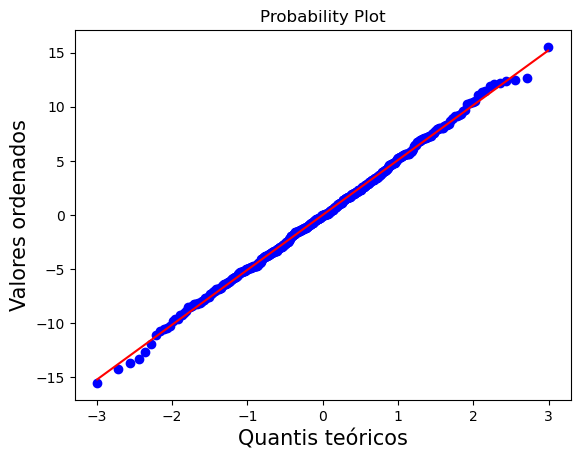

In [8]:
# Pág. 392
import numpy as np 
import scipy.stats as stats
import matplotlib.pyplot as plt

# calcula os resíduos a partir do modelo ajustado
residuals = model_adjusted.resid
# mostra o gráfico quantil-quantil
stats.probplot(residuals, dist="norm",plot=plt)
plt.xlabel('Quantis teóricos', fontsize = 15)
plt.ylabel('Valores ordenados',fontsize = 15)
plt.show(True)

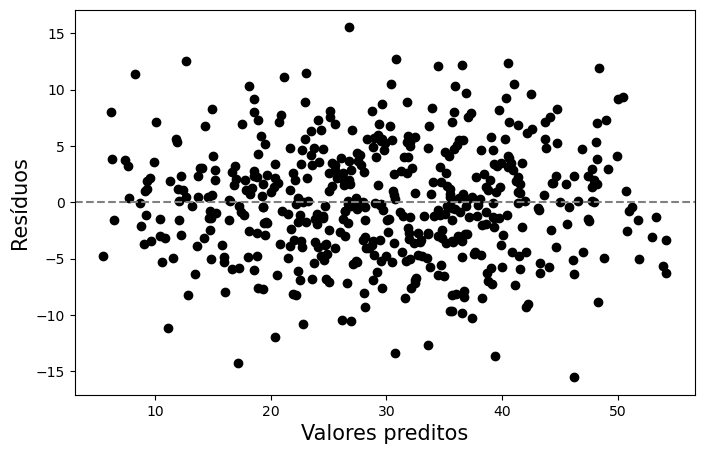

In [9]:
# Pág. 393
plt.figure(figsize=(8,5))
plt.scatter(model_adjusted.fittedvalues, 
            residuals,color='black')
plt.axhline(y = 0, color = 'gray', linestyle = '--')
plt.xlabel('Valores preditos',fontsize = 15)
plt.ylabel('Resíduos', fontsize = 15)
plt.show(True)

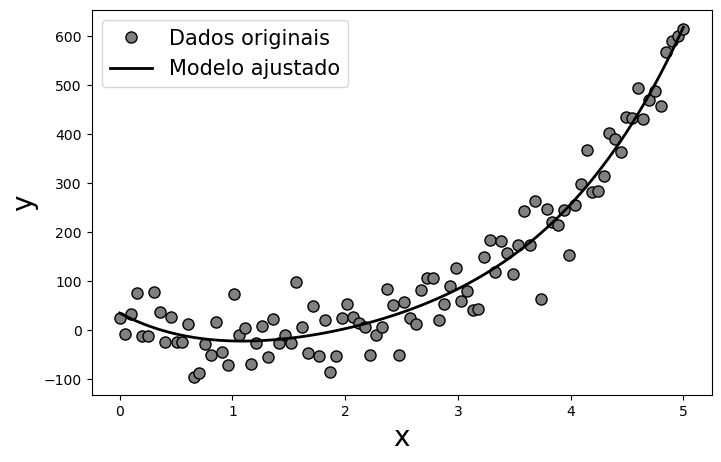

In [10]:
# Pág. 39
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
np.random.seed(42)

# gera os dados
n = 100
x = np.linspace(0,5,n)
y = x**4 + np.random.normal(0,50, n)

# gera os atributos polinomiais
transformer = PolynomialFeatures(degree=4, 
                                 include_bias=False)
x = x.reshape((-1, 1))
transformer.fit(x)
X = transformer.transform(x)

# aplica o modelo
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
# mostra os resultados
plt.figure(figsize=(8,5))
plt.plot(x,y, 'o', color='gray', markersize=8, 
         markerfacecolor='gray', 
         markeredgecolor='black',
        label='Dados originais')
plt.plot(x,y_pred, 'k-',
         linewidth=2, label = 'Modelo ajustado')
plt.ylabel("y", fontsize=20)
plt.xlabel("x", fontsize=20)
plt.legend(fontsize = 15)
plt.show(True) 

In [32]:
# Pág. 397
import pandas as pd

# Faz a leitura dos dados da web
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
data = pd.read_excel(url)
data.head(10)

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.029847
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.698299
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.447770
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.854291
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.289790


In [33]:
# Pág. 398
from sklearn.model_selection import train_test_split
import numpy as np
np.random.seed(42)

# converte para o numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1] # última coluna
X = data[:,0:ncol-1]
# divide o conjunto em treinamento e teste
p = 0.2 # fração de elementos no conjunto de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = p)

In [34]:
# Pág. 398
from sklearn.linear_model import LinearRegression

# modelo de regressão linear multivariado
lm = LinearRegression()
lm.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


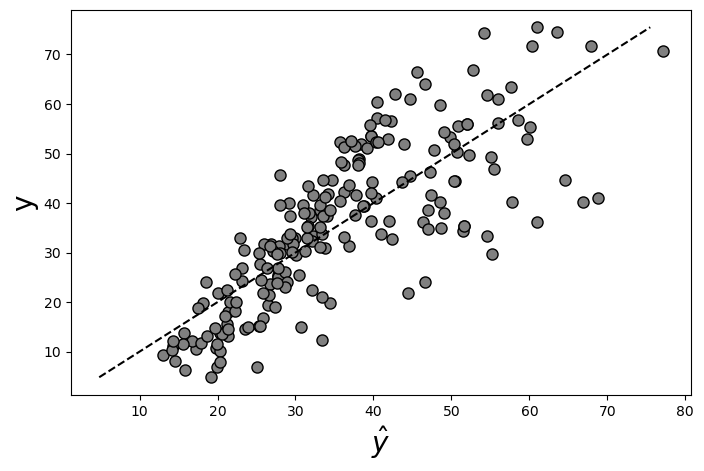

In [35]:
# Pág. 399
import matplotlib.pyplot as plt

# faz a predição no conjunto de teste
y_pred = lm.predict(X_test)
# mostra os resultados
plt.figure(figsize=(8,5))
l = plt.plot(y_pred, y_test, 'o', color='gray', 
         markersize=8, 
         markerfacecolor='gray', 
         markeredgecolor='black')
# mostra a linha x = y
plt.plot([min(y_test),max(y_test)],
         [min(y_test),max(y_test)], 
         color = 'black', linestyle='--')
plt.ylabel("y", fontsize=20)
plt.xlabel(r"$\hat{y}$", fontsize=20)
plt.show(True)


In [36]:
# Pág. 399
from sklearn.metrics import r2_score
R2 = r2_score(y_test, y_pred)
print('R2 = ', R2)

R2 =  0.6275416055429022


In [37]:
# Pág. 400
import numpy as np
np.random.seed(42)
n = 100
X = 2 * np.random.rand(n, 1)
y = 4 + 3 * X + np.random.randn(n, 1)

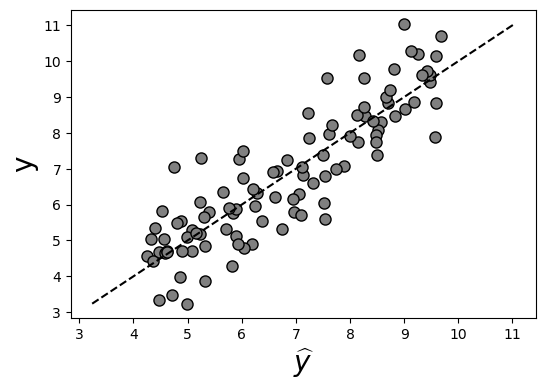

In [38]:
# Pág. 401
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
np.random.seed(42)

n = 100
X = 2 * np.random.rand(n, 1)
y = 4 + 3 * X + np.random.randn(n, 1)
X = X.reshape(-1, 1)

# modelo de regressão
model = LinearRegression()
# treina o modelo
model.fit(X, y)
# faz as predições
y_pred = model.predict(X)

# mostra os resultados
plt.figure(figsize=(6,4))
l = plt.plot(y_pred, y, 'o', color='gray', markersize=8, 
         markerfacecolor='gray', 
         markeredgecolor='black')
# mostra a linha \widehat{y} = y
plt.plot([min(y),max(y)],[min(y),max(y)], 
         color = 'black', linestyle='--')
plt.ylabel("y", fontsize=20)
plt.xlabel(r"$\widehat{y}$", fontsize=20)
plt.show(True)


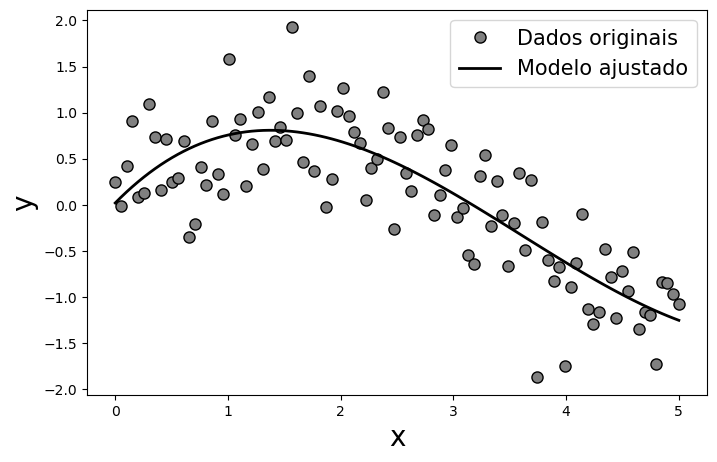

In [39]:
# Pág. 401
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm
np.random.seed(42)

# gera os dados
n = 100
x = np.linspace(0,5,n)
sigma = 0.5
y = np.sin(x) + np.random.normal(0,sigma, n)
# gera os atributos polinomiais
transformer = PolynomialFeatures(degree=3, include_bias=True)
X = transformer.fit_transform(x.reshape(-1,1))  # inclui coluna de 1s

# ajusta o modelo
model = sm.OLS(y, X)
model_adjusted = model.fit()
y_pred = model_adjusted.predict(X)
# mostra os resultados
plt.figure(figsize=(8,5))
plt.plot(x,y, 'o', color='gray', markersize=8, 
         markerfacecolor='gray', 
         markeredgecolor='black',
        label='Dados originais')
plt.plot(x,y_pred, 'k-',linewidth=2, 
         label = 'Modelo ajustado')
plt.ylabel("y", fontsize=20)
plt.xlabel("x", fontsize=20)
plt.legend(fontsize = 15)
plt.show(True) 

In [40]:
# Pág. 403
import pandas as pd

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00291/airfoil_self_noise.dat'
data = pd.read_csv(url, sep='\s+', header = None)
data.columns = ['freq','angle','comp','vel','suc', 'pres']
data.head(10)

,freq,angle,comp,vel,suc,pres
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461
5,2500,0.0,0.3048,71.3,0.002663,125.571
6,3150,0.0,0.3048,71.3,0.002663,125.201
7,4000,0.0,0.3048,71.3,0.002663,123.061
8,5000,0.0,0.3048,71.3,0.002663,121.301
9,6300,0.0,0.3048,71.3,0.002663,119.541


In [41]:
# Pág. 403
import numpy as np
from sklearn.model_selection import train_test_split
np.random.seed(42)

# converte para o formato Numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

# divide o conjunto em treinamento e teste
p = 0.2 # fração de elementos no conjunto de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = p)

In [42]:
# Pág. 404
from sklearn.linear_model import LinearRegression

# modelo de regressão linear multivariado
lm = LinearRegression()
lm.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


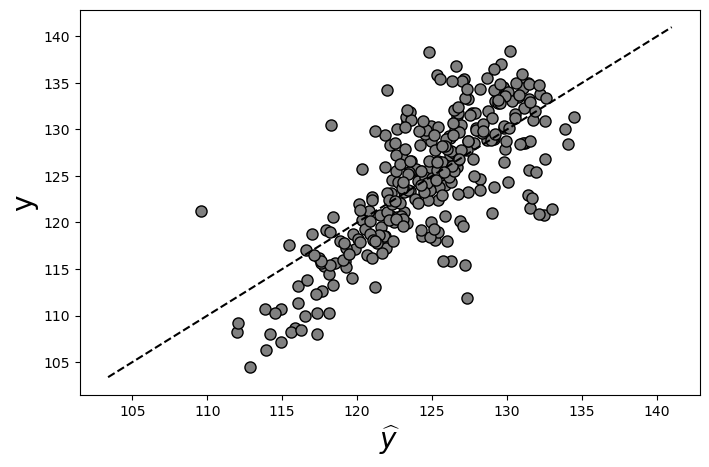

In [43]:
# Pág. 404
import matplotlib.pyplot as plt

# faz a predicao no conjunto de teste
y_pred = lm.predict(X_test)

# mostra os resultados
plt.figure(figsize=(8,5))
plt.plot(y_pred, y_test, 'o', color='gray', 
         markersize=8, 
         markerfacecolor='gray', 
         markeredgecolor='black')
# mostra a linha x = y
plt.plot([min(y),max(y)],[min(y),max(y)], 
         color = 'black', linestyle='--')
plt.ylabel("y", fontsize=20)
plt.xlabel(r"$\widehat{y}$", fontsize=20)
plt.show(True)